<img src="../../shared/alchemi-banner-left.png" alt="NVIDIA ALCHEMI: AI for Chemistry and Materials Science" style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;">

# 08 · Domain decomposition

> **TECHNICALLY VALIDATED DRAFT — HUMAN CELL REVIEW REQUIRED**

**Goal:** Prepare one periodic atomic system for spatial domain decomposition, run the complete public API as a one-process control, and decide whether a separately recorded 1/2/4-GPU campaign is trustworthy enough to analyze.

**Core concepts:** A rank owns the atoms in its spatial subdomain and borrows nearby ghost atoms through a halo. `DomainParallel` coordinates partitioning, halo exchange, model evaluation, migration, and gather around an unchanged `BaseDynamics` workflow.

We reuse [Part 03's model-interface vocabulary](../03-model-interfaces-composition/model-interfaces-composition.ipynb) and [Part 05's `BaseDynamics` lifecycle](../05-base-dynamics/base-dynamics.ipynb). This part adds **one new capability**: split one large periodic system across ranks without rewriting the model or integrator.

<details>
<summary>Where NVIDIA ALCHEMI fits (recap)</summary>

[ALCHEMI](https://developer.nvidia.com/cuda/cuda-x-libraries/alchemi) brings together Python building blocks, accelerated kernels, and deployable services for atomistic workflows.

- **ALCHEMI Toolkit** is a GPU-first Python framework with a unified, composable API for MLIPs and custom models. It provides GPU-native atomic data and batching, model adapters, MD classes, hooks, model training,  and single- to multi-GPU pipelines.   
[GitHub repo](https://github.com/NVIDIA/nvalchemi-toolkit) · [Docs](https://nvidia.github.io/nvalchemi-toolkit/) · Apache 2.0 license

- **Toolkit-Ops** supplies GPU-optimized, batched operations for neighbor lists, dynamics, dispersion, and electrostatics, with PyTorch and JAX bindings.    
[GitHub repo](https://github.com/NVIDIA/nvalchemi-toolkit-ops) · [Docs](https://nvidia.github.io/nvalchemi-toolkit-ops/) · Apache 2.0 license

- **ALCHEMI NIM microservices** package supported atomistic workflows as cloud-ready services. The current catalog includes Batched Geometry Relaxation for structural optimization and Batched Molecular Dynamics.  Self-hosting uses an NVIDIA AI Enterprise license.   
 [Transparency card](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/1.0.0/ai-transparency-card/overview.html) · [Docs](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/latest/index.html)

<img src="../../shared/alchemi-toolkit-architecture.png" alt="NVIDIA ALCHEMI ecosystem showing Toolkit, Toolkit-Ops, and NIM paths for atomistic data, models, simulation workflows, and deployable services." style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;">
</details>

## Course map

<object
  data="../../shared/curriculum-map-08.svg"
  type="image/svg+xml"
  style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;"
  aria-label="ALCHEMI Toolkit curriculum. Part 08 teaches domain decomposition for one large system."
>
  <img src="../../shared/curriculum-map-08.svg" alt="ALCHEMI Toolkit curriculum. Part 08 connects reusable data, models, hooks, dynamics, and GPU execution through spatial domain decomposition." style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;">
</object>

Green marks Part 08. The map places domain decomposition after the data, model, hook, dynamics, and GPU-pipeline foundations it reuses.

In [1]:
import os

_saved_stderr = os.dup(2)
with open(os.devnull, "w") as _null_stderr:
    os.dup2(_null_stderr.fileno(), 2)
    try:
        import helpers
        import matplotlib.pyplot as plt
        import pandas as pd
        import torch
        from IPython.display import display
        from nvalchemi.data import AtomicData, Batch  # noqa: F401
        from nvalchemi.distributed import DistributedManager, DomainConfig, DomainParallel  # isort: skip
        from nvalchemi.dynamics import BaseDynamics
        from nvalchemi.models import LennardJonesModelWrapper
    finally:
        os.dup2(_saved_stderr, 2)
        os.close(_saved_stderr)

In [2]:
import warnings

helpers.configure_presentation()
warnings.filterwarnings("ignore", message="Can't initialize NVML")
warnings.filterwarnings("ignore", message="Could not initialize using ENV")
device = torch.device("cpu")

## Verify the runtime before interpreting it

Version labels are not enough for current-pin evidence. The installed distributions also need the exact VCS commits frozen by this tutorial checkout.

In [3]:
pin_table = helpers.installed_pin_table()
pin_table

,distribution,version,installed VCS commit,pin check
0,nvalchemi-toolkit,0.2.0,8c2c307c1c0c76baee6f7a68eb75a45da83ffd18,match
1,nvalchemi-toolkit-ops,0.4.1,c1e23460859a784e1d78043bcd1c8af0d1095fa2,match


Both rows must say `match`. This proves which implementation the live one-process control uses; it does not create multi-GPU evidence.

## One system, two kinds of atoms

Imagine a periodic box split at the vertical line below. Which atoms must a neighboring rank borrow to evaluate interactions that cross the boundary?

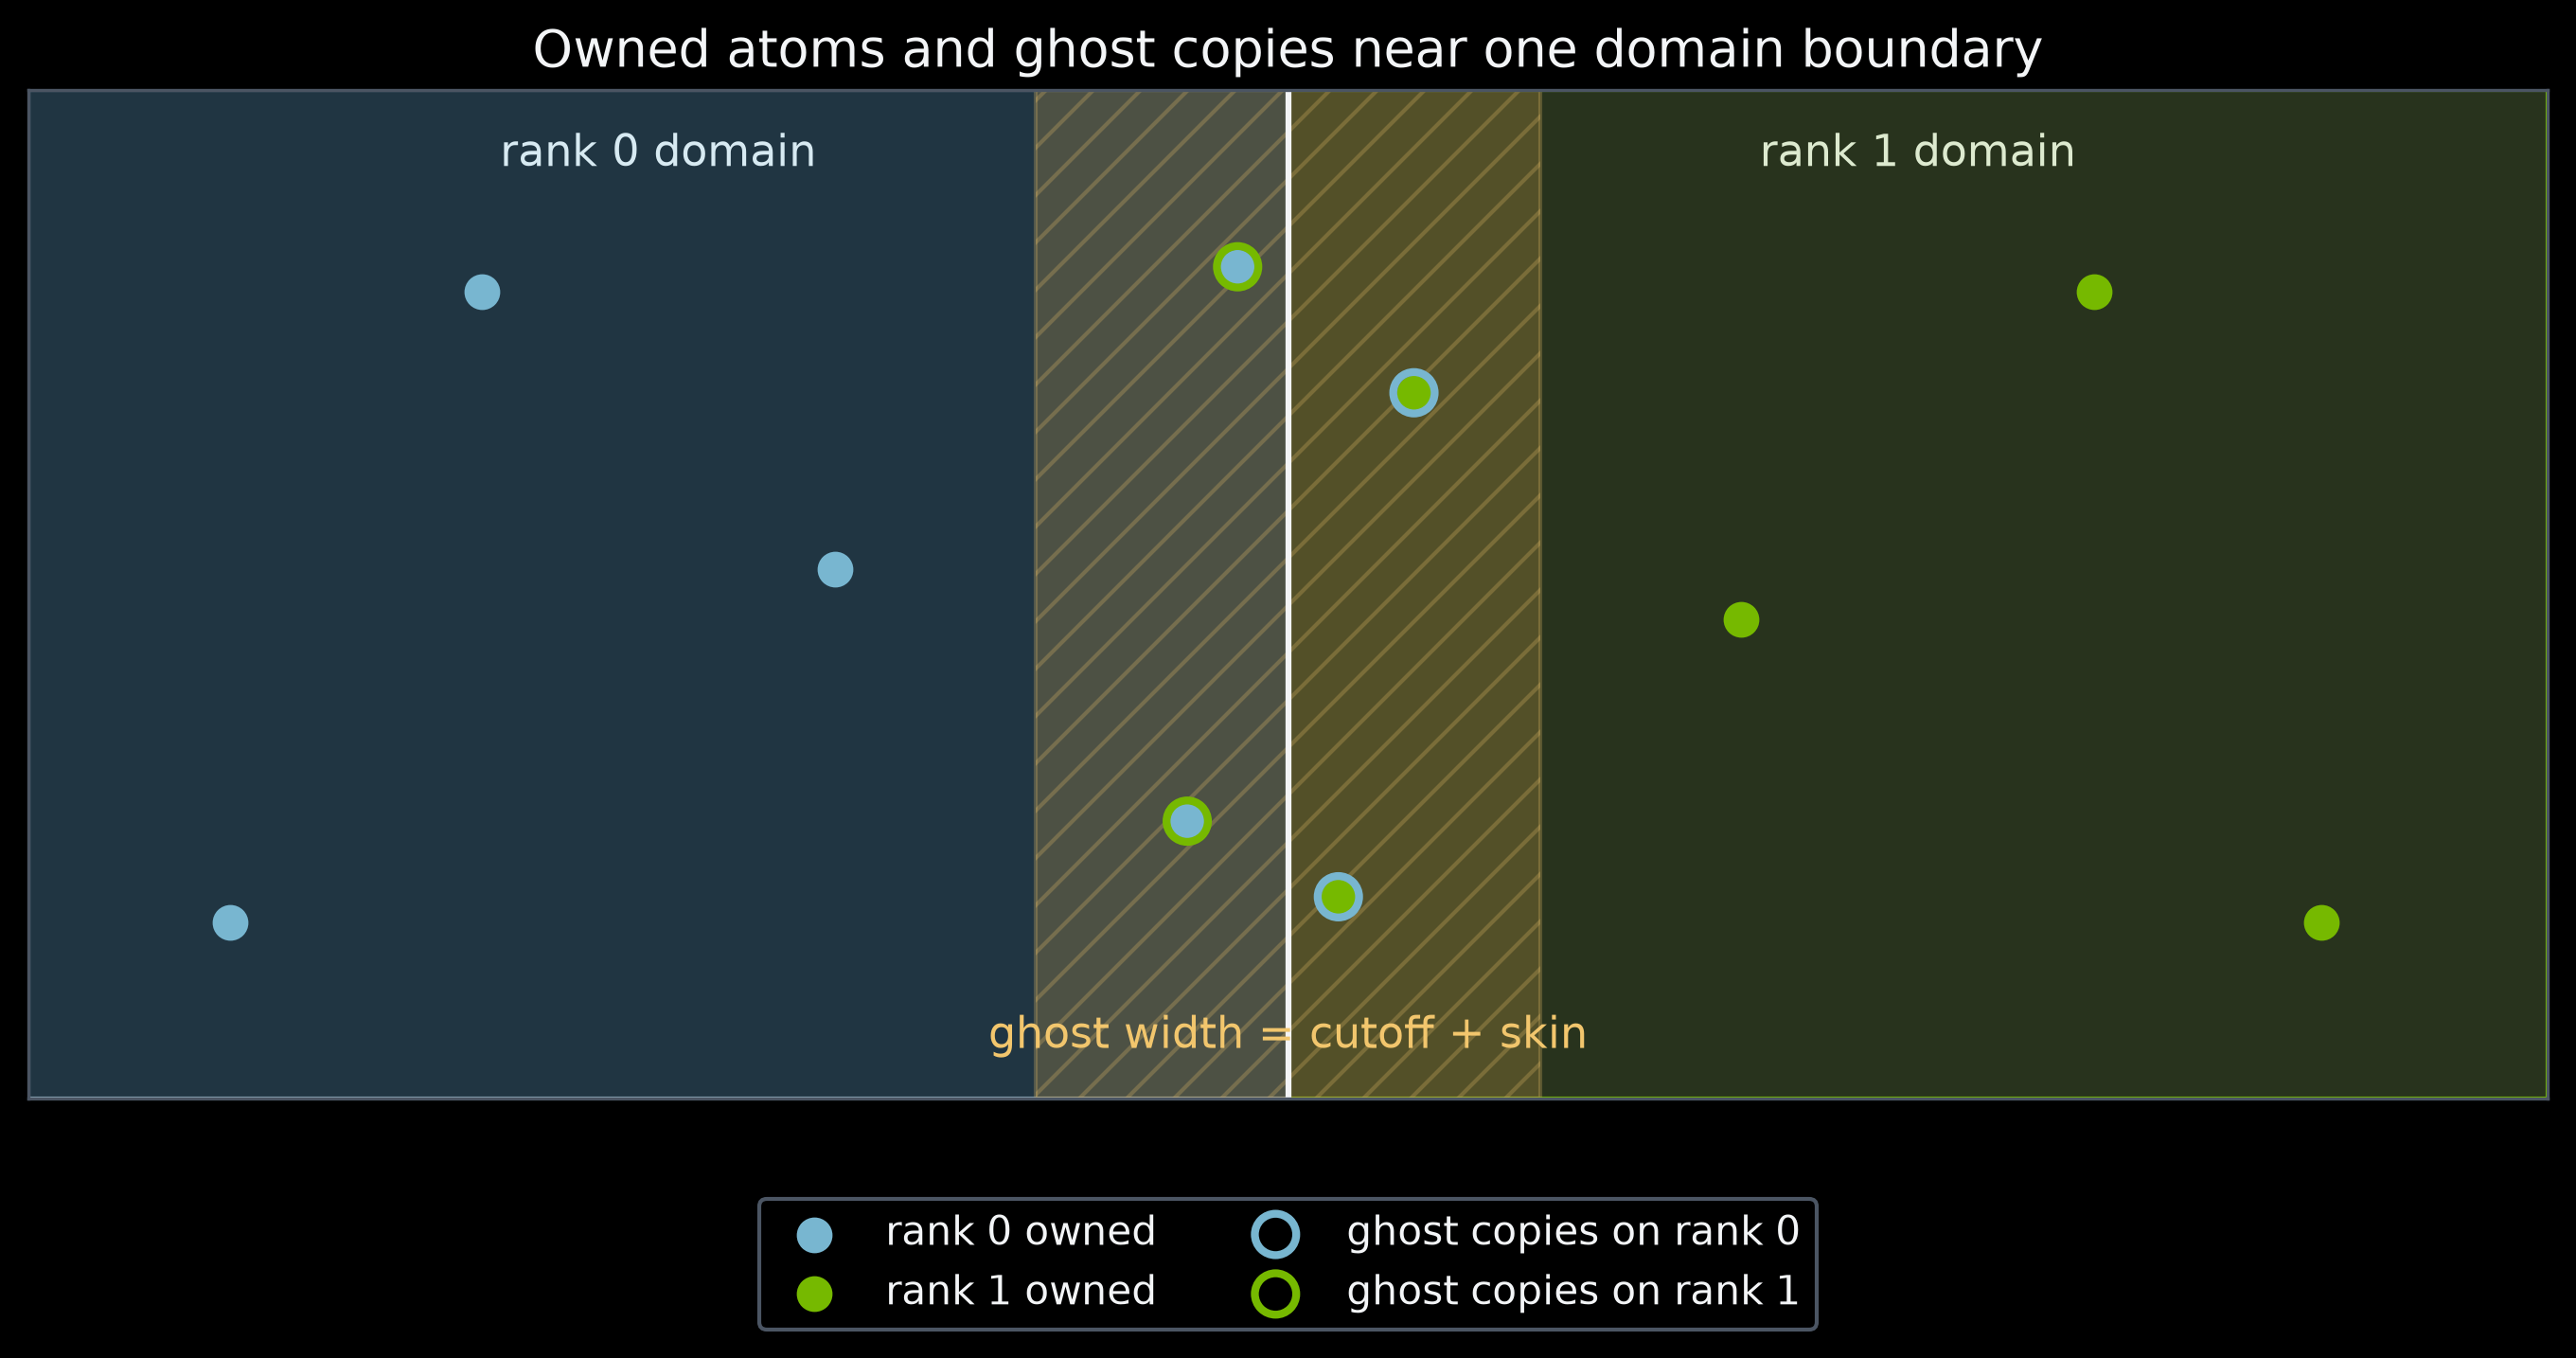

In [4]:
ownership_figure = helpers.plot_domain_ownership()
ownership_alt = "Two spatial domains with owned atoms and outlined ghost copies inside a cutoff-plus-skin halo."
display(
    helpers.accessible_figure(ownership_figure, ownership_alt),
    metadata={"image/png": {"alt": ownership_alt}, "alt": ownership_alt},
)
plt.close(ownership_figure)

Each filled marker has exactly one **owner**. An outlined marker is a **ghost atom**: a read-mostly copy borrowed by the neighboring rank. The halo reaches `cutoff + skin` from the subdomain boundary so every owned atom can see the neighbors its model requires. The sketch isolates one internal boundary; periodic cell faces use the same exchange with wrapped neighbors.

Ghosts do not create extra physical atoms. They create local context. Output consolidation keeps one force row per owned atom and prevents ghost copies from being counted as independent particles.

<div style="display:block;box-sizing:border-box;width:100%;max-width:100%;min-width:0;background:#F2F3F1;color:#1B1E20;border:1px solid #D6D9D4;border-radius:8px;padding:0.78rem 0.95rem;line-height:1.45;overflow:hidden;overflow-wrap:anywhere;">
  <div style="color:#725B22;font-size:0.78rem;font-weight:700;letter-spacing:0.03em;margin-bottom:0.25rem;">💡 Highlight</div>
  <div style="min-width:0;font-size:0.98rem;overflow-wrap:anywhere;">Ownership answers “which rank updates this atom?” The halo answers “which neighboring atoms must that rank read?”</div>
</div>

### One distributed step in plain language

1. `partition(...)` assigns each source atom to one spatial owner.
2. Halo exchange refreshes nearby ghost rows before the model sees the local neighborhood.
3. Every rank computes on its owned-plus-ghost view; reductions turn per-rank contributions into global per-system outputs.
4. A dynamics update may move an owned atom. If it crosses a subdomain boundary, migration transfers ownership before the next compute.
5. `gather(..., dst=0)` reconstructs a full `Batch` on rank 0 when a whole-system view is needed. It returns `None` on every other rank.

Do not gather every step merely for inspection: that defeats the point of keeping state distributed.

## Build a periodic control system

The live example uses the built-in Lennard-Jones wrapper and a 32-atom argon crystal. The model is simple, periodic, checkpoint-free, and already declares its distribution contract. Its 4.5 Å pedagogical cutoff stays below half the 10.52 Å box length and includes the nearest-neighbor shell; this is an API control, not an argon thermodynamics model. The narrow scope keeps ownership mechanics separate from model-download or chemical-suitability questions.

In [5]:
domain_batch = helpers.build_argon_control(device=device)
assert isinstance(domain_batch, Batch)
{
    "atoms": domain_batch.num_nodes,
    "cell lengths (Å)": domain_batch.cell.diagonal(dim1=-2, dim2=-1),
    "periodic": domain_batch.pbc,
}

{'atoms': 32,
 'cell lengths (Å)': tensor([[10.5200, 10.5200, 10.5200]]),
 'periodic': tensor([[True, True, True]])}

In [6]:
field_frame = pd.DataFrame([
    ("positions", tuple(domain_batch.positions.shape), "per-node"),
    ("forces", tuple(domain_batch.forces.shape), "per-node"),
    ("source_atom_id", tuple(domain_batch.source_atom_id.shape), "per-node"),
    ("energy", tuple(domain_batch.energy.shape), "per-graph"),
    ("cell", tuple(domain_batch.cell.shape), "per-graph"),
], columns=["field", "shape", "ownership level"])
field_frame

,field,shape,ownership level
0,positions,"(32, 3)",per-node
1,forces,"(32, 3)",per-node
2,source_atom_id,"(32,)",per-node
3,energy,"(1, 1)",per-graph
4,cell,"(1, 3, 3)",per-graph


`source_atom_id` is a stable identity, not a model input. A spatial scatter may reorder rows into rank-contiguous blocks; keeping this field lets a later gather restore source order before force parity is tested.

In [7]:
model = LennardJonesModelWrapper(
    epsilon=0.0104,
    sigma=3.40,
    cutoff=4.5,
    switch_width=0.5,
).eval()

<div style="display:block;box-sizing:border-box;width:100%;max-width:100%;min-width:0;background:#111619;color:#F3F4F6;border:1px solid #2E353B;border-radius:10px;padding:0.9rem 1rem;line-height:1.45;overflow:hidden;overflow-wrap:anywhere;">
  <div style="color:#76B900;font-size:0.72rem;font-weight:700;letter-spacing:0.055em;margin-bottom:0.45rem;">ALCHEMI TOOLKIT API</div>
  <code style="display:block;color:#FFFFFF;font-size:1.02rem;font-weight:650;white-space:normal;overflow-wrap:anywhere;">model.distribution_spec(strategy) -&gt; MLIPSpec</code>
  <div style="border-top:1px solid #2E353B;margin-top:0.7rem;padding-top:0.65rem;color:#CDD2D8;font-size:0.92rem;">
    <div><strong style="color:#F3F4F6;">Declares</strong> · storage policy, sharded fields, operation adapters, output kinds, and reduction behavior.</div>
    <div style="margin-top:0.25rem;"><strong style="color:#F3F4F6;">Used by</strong> · the distributed model adapter created inside <code style="color:#FFFFFF;">DomainParallel</code>.</div>
  </div>
</div>

In [8]:
lj_spec = model.distribution_spec()
{
    "contract": type(lj_spec).__name__,
    "storage policy": type(lj_spec.distribution.policy).__name__,
    "sharded fields": lj_spec.distribution.shard_fields,
    "system reductions": lj_spec.system_reductions,
    "output kinds": {key: value.value for key, value in lj_spec.output_kinds.items()},
}

{'contract': 'MLIPSpec',
 'storage policy': 'HaloStoragePolicy',
 'sharded fields': ('positions', 'charges', 'atomic_numbers'),
 'system reductions': True,
 'output kinds': {'energy': 'per_graph',
  'forces': 'per_node',
  'stress': 'per_graph',
  'atomic_energies': 'per_node'}}

A custom wrapper follows the same rule: implement `distribution_spec(strategy)` and return an `MLIPSpec`. The spec must distinguish per-node outputs such as forces from per-graph outputs such as energy, declare how sharded inputs are stored, and adapt any operation that cannot consume distributed tensors directly. A numerically correct single-GPU wrapper is not automatically distribution-safe.

For this built-in model, `HaloStoragePolicy` means each rank evaluates owned atoms with local ghost context. `system_reductions=True` tells the framework that extensive system quantities need owner-aware cross-rank consolidation.

### Establish a direct reference

A fresh `BaseDynamics` evaluator computes the same fixed structure without the `DomainParallel` wrapper. This is a control for the live fallback, not a multi-GPU reference.

In [9]:
reference_batch = helpers.build_argon_control(device=device)
direct_evaluator = BaseDynamics(
    model=model,
    n_steps=1,
    hooks=model.make_neighbor_hooks(),
)
reference_result = direct_evaluator.run(reference_batch, n_steps=1)

## Execute the supported public path

The sequence below is the same user-facing route used by a real distributed job:

`DistributedManager → mesh → DomainConfig → DomainParallel → partition → run → gather`

Here it runs in one ordinary notebook process. **One process does not partition the system.** The point is to validate configuration, lifecycle, fields, and gather semantics before scale-out.

In [10]:
DistributedManager.initialize()
manager = DistributedManager()
world_size = manager.world_size
mesh = (
    manager.initialize_mesh(
        mesh_shape=(world_size,), mesh_dim_names=("domain",)
    )
    if manager.distributed
    else None
)
{"world size": world_size, "rank": manager.rank, "mesh": mesh}

{'world size': 1, 'rank': 0, 'mesh': None}

In this ordinary one-process session, no process group was created, so the mesh is `None`. That is the documented one-process fallback: `DomainConfig` still records the intended domain settings, while a real externally launched job creates a device mesh spanning its ranks.

In [11]:
domain_config = DomainConfig(
    cutoff=float(model.model_config.neighbor_config.cutoff),
    skin=0.25,
    mesh=mesh,
    grid_dims=(1, 1, 1),
    compile=False,
)

In [12]:
domain_evaluator = BaseDynamics(
    model=model,
    n_steps=1,
    hooks=model.make_neighbor_hooks(),
)

What should `partition(...)` return when there is only rank 0? Track the atom count through all three objects.

In [13]:
try:
    domain = DomainParallel(
        dynamics=domain_evaluator,
        config=domain_config,
        n_steps=1,
        device_type=device.type,
    )
    with domain:
        owned_batch = domain.partition(domain_batch)
        domain_result = domain.run(owned_batch, n_steps=1)
        gathered_result = domain.gather(domain_result, dst=0)
finally:
    DistributedManager.cleanup()

In [14]:
control_summary = helpers.control_summary(
    world_size=world_size,
    full_batch=domain_batch,
    owned_batch=owned_batch,
    gathered_batch=gathered_result,
)
control_summary

{'world size': 1,
 'input atoms': 32,
 'rank-0 owned atoms': 32,
 'gathered atoms': 32,
 'spatially decomposed': False,
 'interpretation': 'one-process control; no partition'}

All 32 atoms remain owned by rank 0, and the gathered batch still has 32 atoms. No communication occurred, no ghost rows were needed, and no load was shared. This is a one-process fallback and **not a scaling result**.

In [15]:
assert gathered_result is not None
torch.testing.assert_close(gathered_result.energy, reference_result.energy)
torch.testing.assert_close(gathered_result.forces, reference_result.forces)
{
    "maximum |ΔE| (eV)": float((gathered_result.energy - reference_result.energy).abs().max()),
    "maximum |ΔF| (eV/Å)": float((gathered_result.forces - reference_result.forces).abs().max()),
}

{'maximum |ΔE| (eV)': 0.0, 'maximum |ΔF| (eV/Å)': 0.0}

Do the direct and wrapped one-process paths land on the identity line, and is any residual visible at this precision?

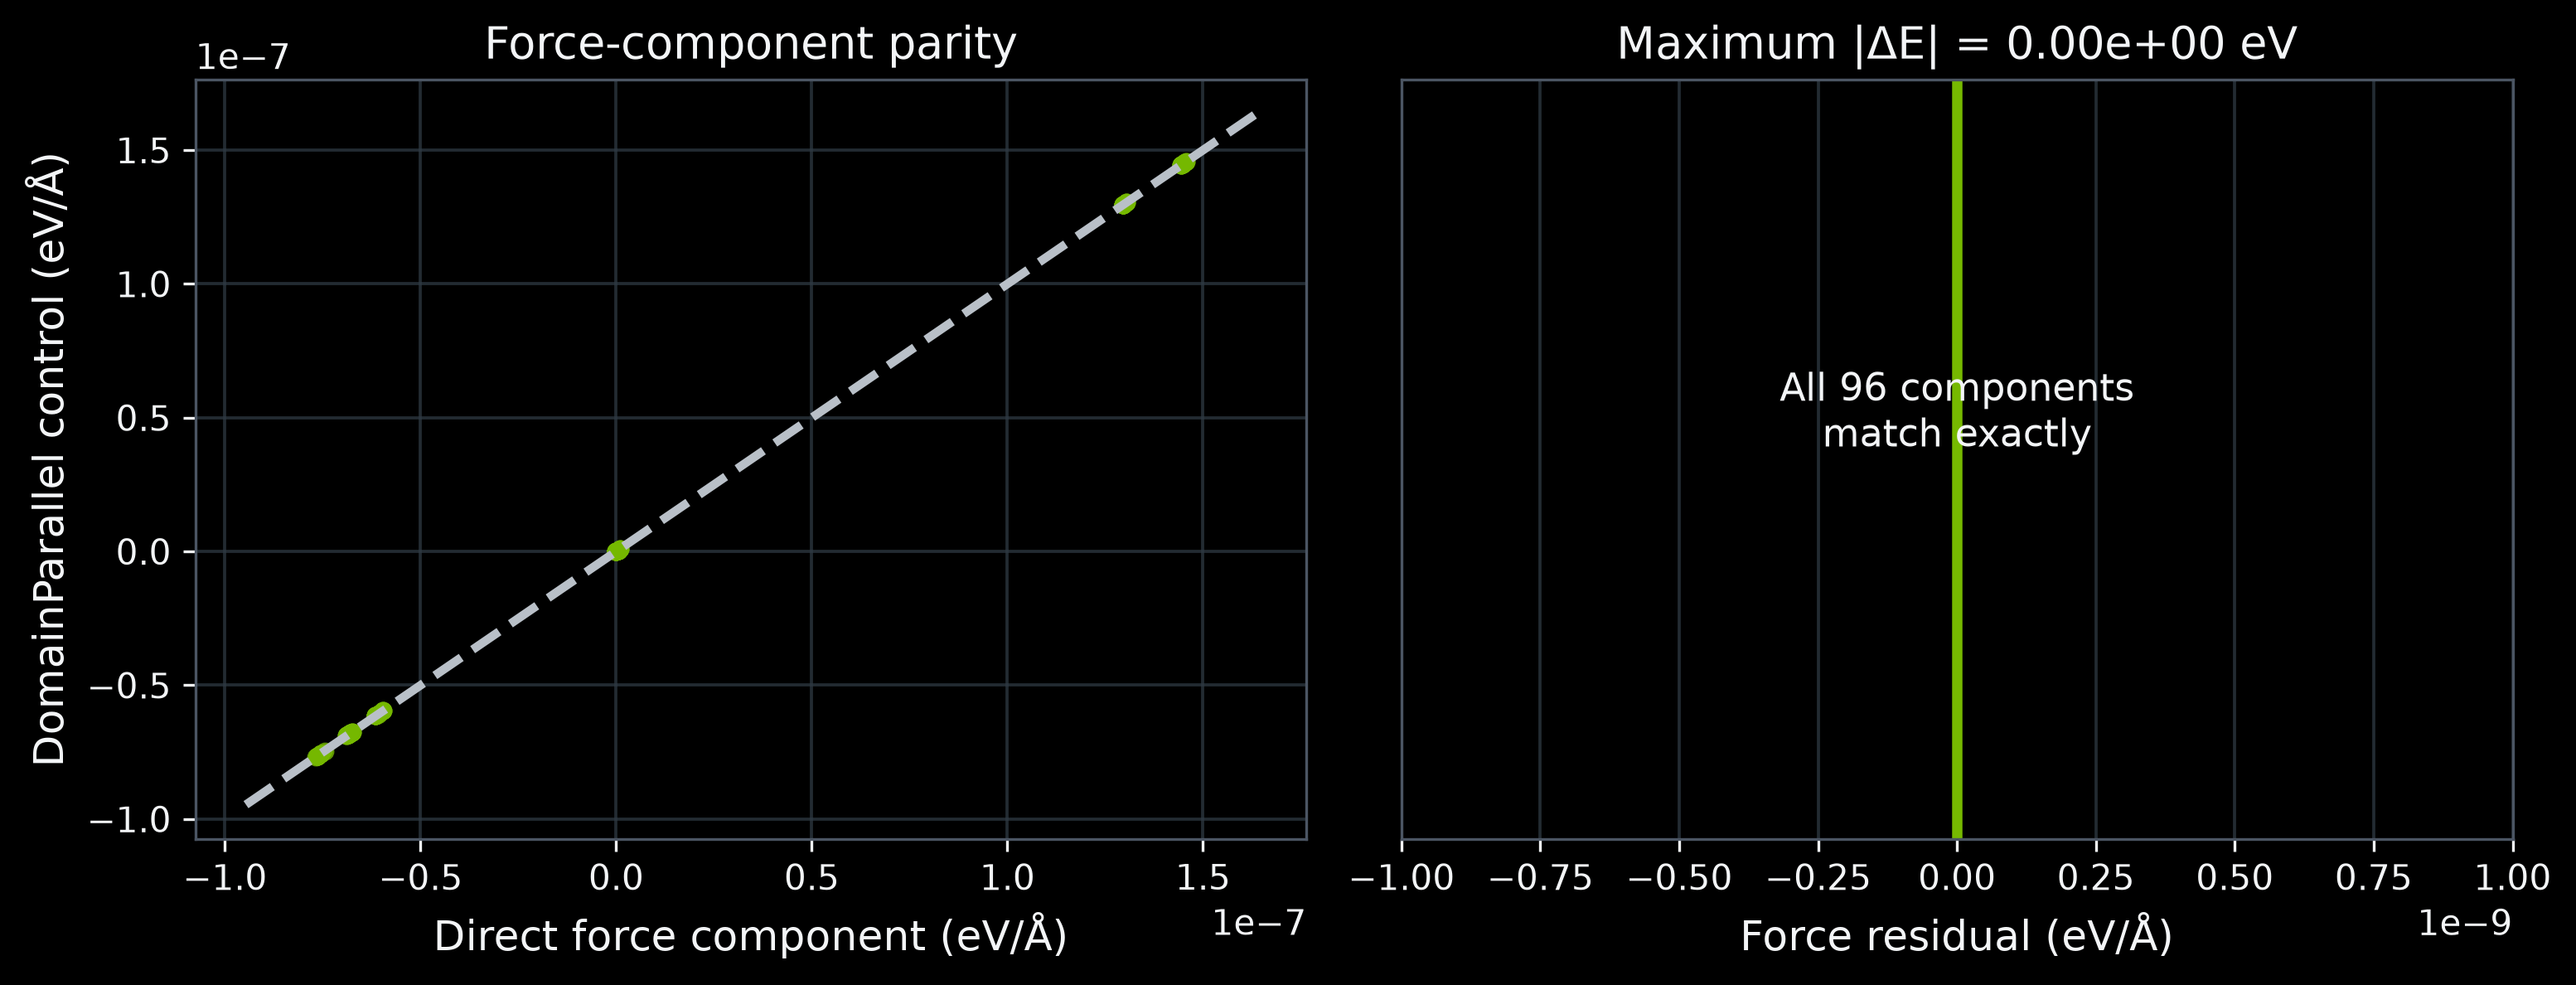

In [16]:
parity_alt = "Direct versus one-process DomainParallel force components on the identity line, with residuals."
control_parity_figure = helpers.plot_control_parity(
    reference_result, gathered_result
)
display(
    helpers.accessible_figure(control_parity_figure, parity_alt),
    metadata={"image/png": {"alt": parity_alt}, "alt": parity_alt},
)
plt.close(control_parity_figure)

The points overlap the identity line because `DomainParallel` delegated to the same local dynamics path. This proves the fallback did not alter the result. It does **not** test halo exchange, a collective reduction, multi-rank ordering, or communication cost.

## What changes when world size exceeds one

- **Partition:** rank 0 supplies the full `Batch`; every rank receives only its owned rows. The sum of owned counts must equal the global atom count exactly.
- **Halo exchange:** boundary neighbors are copied to adjacent ranks out to the ghost width, `cutoff + skin`. The public API does not expose halo counts, so the campaign records them as unavailable instead of guessing.
- **Compute and reduction:** forces are per-node outputs consolidated onto owners. Energy is a per-graph extensive output assembled from owner-aware system reductions.
- **Migration:** if dynamics moves an atom across a boundary, its owner changes before the next force evaluation. Periodic wrapping may change the stored image without changing the physical position.
- **Gather:** `gather(..., dst=0)` is collective. Rank 0 receives a full batch; other ranks receive `None`. `source_atom_id` restores input order before comparing force rows.

### Hooks need an explicit rank scope

`HookScope.LOCAL` runs on every rank with that rank's owned batch. `HookScope.GLOBAL` gathers the complete system onto every rank and then runs the callback on every rank. `HookScope.RANK_ZERO` gathers once and runs only on rank 0. Use the last scope for single-writer logging or artifacts; use `GLOBAL` only when every callback truly needs the full system, because it communicates and duplicates the batch. Writing the same path from every rank is a race, not distributed observability.

## Domain decomposition is not distributed pipeline parallelism

**Domain decomposition** gives several ranks spatial pieces of **one large periodic system**. Every rank participates in one model/dynamics step.

**Distributed pipeline parallelism** assigns **different model stages or dynamics stages** to ranks and passes systems between them. It helps when a workflow has stage-level concurrency or heterogeneous costs.

They solve different bottlenecks. Toolkit can combine them on a two-dimensional mesh, but that is an advanced composition—not a reason to blur their contracts. See the official [distributed simulation design](https://nvidia.github.io/nvalchemi-toolkit/userguide/distributed.html), [GPU pipeline guide](https://nvidia.github.io/nvalchemi-toolkit/modules/dynamics/distributed_pipeline.html), and [distributed examples](https://nvidia.github.io/nvalchemi-toolkit/examples/distributed/index.html).

## The real periodic scale-out case

The campaign input starts from a checked 3,200-atom phenol/N-methylacetamide box. It is a Packmol starting configuration at a declared construction density—not an equilibrated liquid or a density prediction.

In [17]:
base_box = helpers.base_box_identity()
pd.DataFrame(
    base_box.items(),
    columns=["checked field", "base-box value"],
)

,checked field,base-box value
0,system,phenol + N-methylacetamide
1,atom_count,3200
2,molecule_count,256
3,molecules_per_species,128
4,construction_density_g_cm3,1.0
5,pbc,"[True, True, True]"
6,structure_sha256,5fcfc9394ebed3583267f20f322f60fb7b9311650e3b8dec4b8e8edaa4e0c0da
7,manifest_sha256,ea30e3f12f042f98f136147e783b56ab2e0da622f3486718b9fec69f3cde74b4
8,scope,Packmol produced one periodic starting configuration at the declared construction dens...


The exact scale-out input repeats this base box by 2 × 2 × 4, yielding 51,200 atoms and 2,048 molecules of each species. Every GPU count must consume the same resulting tensor identity.

In [18]:
campaign_path = helpers.campaign_spec_path()
campaign = helpers.read_campaign_spec(campaign_path)
helpers.campaign_workload_frame(campaign)

,field,exact campaign value
0,system,phenol + N-methylacetamide
1,atoms,"51,200"
2,molecules per species,"2,048"
3,repeat factors,2 × 2 × 4
4,periodic,True
5,model adapter,AIMNet2Wrapper
6,model scope,Current-pin short-range AIMNet2 adapter only. This campaign checks decomposition parit...
7,cutoff / skin,5.0 Å / 1.0 Å
8,required GPUs,"1, 2, 4"


### Current-pin evidence gate

A campaign is eligible only when all case records match these identities:

- Toolkit commit: `8c2c307c1c0c76baee6f7a68eb75a45da83ffd18`
- Toolkit-Ops commit: `c1e23460859a784e1d78043bcd1c8af0d1095fa2`
- AIMNet2 checkpoint SHA-256: `f0f7c054539ad3261bd36f9b11c56d12f87cb723e25bea7521755bbd3ec24e28`
- base-box structure SHA-256: `5fcfc9394ebed3583267f20f322f60fb7b9311650e3b8dec4b8e8edaa4e0c0da`
- generated input-tensor SHA-256: `56b9d1c71c9c392a2e12ad8149f3ca0cb0ab816fd4926af42fd264e8874d9a36`
- world sizes: 1, 2, and 4, run serially on the same fixed 51,200-atom input

The gate also requires complete rank ownership, source-ordered outputs, periodic position invariance, synchronized timing, finite values, energy parity, and force parity.

In [19]:
campaign_report = helpers.validate_campaign(
    campaign, root=campaign_path.parent
)
helpers.evidence_status_frame(campaign_report)

,evidence status,plot eligible,reason
0,NOT REPORTED,False,No complete 1/2/4-GPU campaign has been recorded with the current tutorial runtime pin...


The checked-in state is `NOT REPORTED`: this environment has no complete 1/2/4-GPU result bundle at the current pins. The older H100 bundle remains **archived methodology**, not current evidence. Its numbers are neither copied nor plotted here.

In [20]:
if campaign_report.ready:
    display(campaign_report.table)
    campaign_figure = helpers.plot_campaign(campaign_report)
    display(
        campaign_figure,
        metadata={"image/png": {"alt": "Current-pin median evaluation time and maximum force difference for one, two, and four GPUs."}},
    )
    plt.close(campaign_figure)
else:
    print("NOT REPORTED — no scaling or parity plot is drawn.")

NOT REPORTED — no scaling or parity plot is drawn.


No empty chart appears, because an unlabeled placeholder can look like data. Once a complete current-pin bundle passes, the same cell reveals raw timing, speedup, parallel efficiency, energy difference per atom, maximum force-component difference, and parity status.

### Reproduce the missing evidence outside the notebook

The [external campaign instructions](external/README.md) run one world-size case at a time and write a checksum-gated manifest under `results/current-pin/`. The runner itself never starts another process, opens a remote session, or asks for input; a user-controlled distributed launcher starts it externally.

Each case records installed commit provenance, input and checkpoint checksums, per-rank owned-atom counts, GPU/runtime identity, one untimed warm-up, three synchronized equal-work passes, gathered source IDs, energy, forces, and artifact checksums. GPU work is serialized: the next world size begins only after the previous case exits.

### Parity comes before performance

For every multi-rank case, compare against the one-GPU result for the exact same input:

- normalize the extensive energy difference by atom count and require it below the declared tolerance;
- reorder force rows by `source_atom_id`, then apply the declared componentwise absolute and relative tolerances;
- verify the owned counts contain one entry per rank and sum to 51,200;
- verify periodic positions changed by no more than the minimum-image tolerance;
- reject a case if any checksum, pin, rank record, finite-value check, or parity check fails.

A fast wrong answer is not scaling.

### What timing could—and could not—show

A passing fixed-input campaign could report **observed** latency, speedup, efficiency, ownership balance, and parity for one node, this model, this box, and these pins. It could reveal that communication or imbalance dominates at a particular world size.

It could not establish universal scaling, multi-node behavior, trajectory stability, equilibration, production accuracy, or the best decomposition for another cell shape. Strong scaling eventually loses to halo surface-to-volume cost, collective reductions, launch overhead, and the slowest rank. Three short passes are a diagnostic, not a publishable benchmark.

## Try it: reason about the halo before changing a run

The live configuration uses a 4.5 Å cutoff and 0.25 Å skin. Increase the skin below. How does the ghost width change, and what trade-off follows?

In [21]:
try_skin = 0.5
try_ghost_width = domain_config.cutoff + try_skin
{
    "cutoff (Å)": domain_config.cutoff,
    "skin (Å)": try_skin,
    "ghost width (Å)": try_ghost_width,
}

{'cutoff (Å)': 4.5, 'skin (Å)': 0.5, 'ghost width (Å)': 5.0}

A wider skin delays some neighbor-list rebuilds or migrations, but sends and stores more ghost atoms. There is no universally optimal value: motion per step, cutoff, density, cell shape, and network topology all matter. This arithmetic exercise does not rerun the distributed campaign.

## Advanced model option: UMA in a separate environment

Toolkit provides `UMAWrapper` for Universal Models for Atoms and a matching halo distribution spec, but the UMA/fairchem dependency stack conflicts with this locked CUDA extras stack. Follow the official [UMA model guidance](https://nvidia.github.io/nvalchemi-toolkit/userguide/models.html#using-uma-fairchem-core) in a **separate environment**. Do not install or run UMA in this tutorial lock merely to substitute a model in the example.

## Recap

### What you learned

- Domain decomposition gives each atom one spatial owner and supplies boundary context through ghost atoms.
- The public path is `DistributedManager → mesh → DomainConfig → DomainParallel → partition → run → gather`.
- A world-size-one notebook validates that path but performs no partition, communication, or scaling measurement.
- A distribution-safe model declares its sharded fields, operation adapters, output kinds, and reductions through `MLIPSpec`.
- Exact-input parity, rank ownership, checksums, and current-pin provenance must pass before timing is interpreted.

### What the evidence does not show

The current tutorial contains no current-pin multi-GPU measurement, so its honest result is `NOT REPORTED`. The archived H100 campaign teaches methodology only. No claim about speedup, efficiency, multi-node behavior, or phenol/NMA production science follows from the live one-process control.

### Continue the course

Return to the [Core playbook](../00-core-playbook/alchemi-core-playbook.ipynb), revisit [model interfaces](../03-model-interfaces-composition/model-interfaces-composition.ipynb) or [dynamics](../05-base-dynamics/base-dynamics.ipynb), compare with the official [GPU pipeline](https://nvidia.github.io/nvalchemi-toolkit/modules/dynamics/distributed_pipeline.html), or explore Toolkit [R&D examples](https://github.com/NVIDIA/nvalchemi-toolkit/tree/main/examples/advanced).

### Human review required

Technical execution, schema, provenance gates, and learner-facing outputs can be checked automatically. A human reviewer still needs to approve the scientific copy, diagram legibility, notebook pacing, accessibility, and the external 1/2/4-GPU campaign when current hardware produces it. Until that review—and until the campaign gate passes—the draft status at the top remains accurate for this release.